In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [4]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [5]:
from sklearn.preprocessing import StandardScaler

 # 1. Load The Dataset :

In [12]:
df = pd.read_csv("ecommerce_customer_data_custom_ratios.csv")
print(df)

        Customer ID        Purchase Date Product Category  Product Price  \
0             46251  2020-09-08 09:38:32      Electronics             12   
1             46251  2022-03-05 12:56:35             Home            468   
2             46251  2022-05-23 18:18:01             Home            288   
3             46251  2020-11-12 13:13:29         Clothing            196   
4             13593  2020-11-27 17:55:11             Home            449   
...             ...                  ...              ...            ...   
249995        33308  2023-08-10 13:39:06         Clothing            279   
249996        48835  2021-11-23 01:30:42             Home             27   
249997        21019  2020-07-02 14:04:48             Home             17   
249998        49234  2020-12-30 02:02:40            Books            398   
249999        16971  2021-03-13 16:28:35      Electronics            425   

        Quantity  Total Purchase Amount Payment Method  Customer Age  Returns  \
0     

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  str    
 2   Product Category       250000 non-null  str    
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  str    
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  str    
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  str    
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), str(5)
memory usage: 37.1 MB


In [16]:
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.00000,250000.000000,250000.000000,250000.000000,250000.000000,202404.000000,250000.000000,250000.000000
mean,25004.03624,254.659512,2.998896,2725.370732,43.940528,0.497861,43.940528,0.199496
std,14428.27959,141.568577,1.414694,1442.933565,15.350246,0.499997,15.350246,0.399622
min,1.00000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.000000
25%,12497.75000,132.000000,2.000000,1477.000000,31.000000,0.000000,31.000000,0.000000
50%,25018.00000,255.000000,3.000000,2724.000000,44.000000,0.000000,44.000000,0.000000
75%,37506.00000,377.000000,4.000000,3974.000000,57.000000,1.000000,57.000000,0.000000
max,50000.00000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.000000


In [18]:
df.shape

(250000, 13)

In [20]:
df.dtypes

Customer ID                int64
Purchase Date                str
Product Category             str
Product Price              int64
Quantity                   int64
Total Purchase Amount      int64
Payment Method               str
Customer Age               int64
Returns                  float64
Customer Name                str
Age                        int64
Gender                       str
Churn                      int64
dtype: object

In [22]:
df["Purchase Date"] = pd.to_datetime(df["Purchase Date"])
print(df["Purchase Date"].dtype)

datetime64[us]


In [24]:
df.duplicated().sum()

0

In [26]:
df.isnull().value_counts()

Customer ID  Purchase Date  Product Category  Product Price  Quantity  Total Purchase Amount  Payment Method  Customer Age  Returns  Customer Name  Age    Gender  Churn
False        False          False             False          False     False                  False           False         False    False          False  False   False    202404
                                                                                                                            True     False          False  False   False     47596
Name: count, dtype: int64

In [30]:
print(df.isnull().mean())

Customer ID              0.000000
Purchase Date            0.000000
Product Category         0.000000
Product Price            0.000000
Quantity                 0.000000
Total Purchase Amount    0.000000
Payment Method           0.000000
Customer Age             0.000000
Returns                  0.190384
Customer Name            0.000000
Age                      0.000000
Gender                   0.000000
Churn                    0.000000
dtype: float64


In [32]:
print(df.isnull().sum())

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47596
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64


# 2.Descriptive Statistics :

In [34]:
Avg_Purchase_value = df["Total Purchase Amount"].mean()
print("Avergae Purchase Amount of Customers :",Avg_Purchase_value)

Avergae Purchase Amount of Customers : 2725.370732


In [36]:
# Monthly sales
monthly_sales = (
    df.resample("ME", on="Purchase Date")["Total Purchase Amount"]
    .sum()
    .reset_index()
    .rename(columns={"Total Purchase Amount": "total_amount"})
)
monthly_sales["month"] = monthly_sales["Purchase Date"].dt.to_period("M").astype(str)

print("\nMonthly Sales:")
print(monthly_sales[["month", "total_amount"]])


Monthly Sales:
      month  total_amount
0   2020-01      15442459
1   2020-02      14561593
2   2020-03      15537311
3   2020-04      14847491
4   2020-05      15395782
5   2020-06      14980739
6   2020-07      16003821
7   2020-08      15954931
8   2020-09      14969811
9   2020-10      15799599
10  2020-11      15497095
11  2020-12      16285542
12  2021-01      15522423
13  2021-02      14207789
14  2021-03      16037760
15  2021-04      14955289
16  2021-05      15468549
17  2021-06      15153850
18  2021-07      15399655
19  2021-08      15417951
20  2021-09      14841329
21  2021-10      15455040
22  2021-11      15161094
23  2021-12      15222674
24  2022-01      15917637
25  2022-02      14153776
26  2022-03      15786644
27  2022-04      14477271
28  2022-05      15780614
29  2022-06      15084793
30  2022-07      15663572
31  2022-08      15484872
32  2022-09      14853703
33  2022-10      15450420
34  2022-11      14997555
35  2022-12      15274645
36  2023-01      15495

In [38]:
# Quarterly sales
quarterly_sales = (
    df.resample("QE", on="Purchase Date")["Total Purchase Amount"]
    .sum()
    .reset_index()
    .rename(columns={"Total Purchase Amount": "total_amount"})
)
quarterly_sales["quarter"] = quarterly_sales["Purchase Date"].dt.to_period("Q").astype(str)


print("\nQuarterly Sales:")
print(quarterly_sales[["quarter", "total_amount"]])


Quarterly Sales:
   quarter  total_amount
0   2020Q1      45541363
1   2020Q2      45224012
2   2020Q3      46928563
3   2020Q4      47582236
4   2021Q1      45767972
5   2021Q2      45577688
6   2021Q3      45658935
7   2021Q4      45838808
8   2022Q1      45858057
9   2022Q2      45342678
10  2022Q3      46002147
11  2022Q4      45722620
12  2023Q1      45744435
13  2023Q2      46000164
14  2023Q3      38553005


In [40]:
# Yearly sales
yearly_sales_df = (
    df.groupby(df["Purchase Date"].dt.year)["Total Purchase Amount"].sum()
    .reset_index()
    .rename(columns = {"Purchase Date":"year","Sales":"total_amount"})
)

print("Yearly Sales:")
print(yearly_sales_df)

Yearly Sales:
   year  Total Purchase Amount
0  2020              185276174
1  2021              182843403
2  2022              182925502
3  2023              130297604


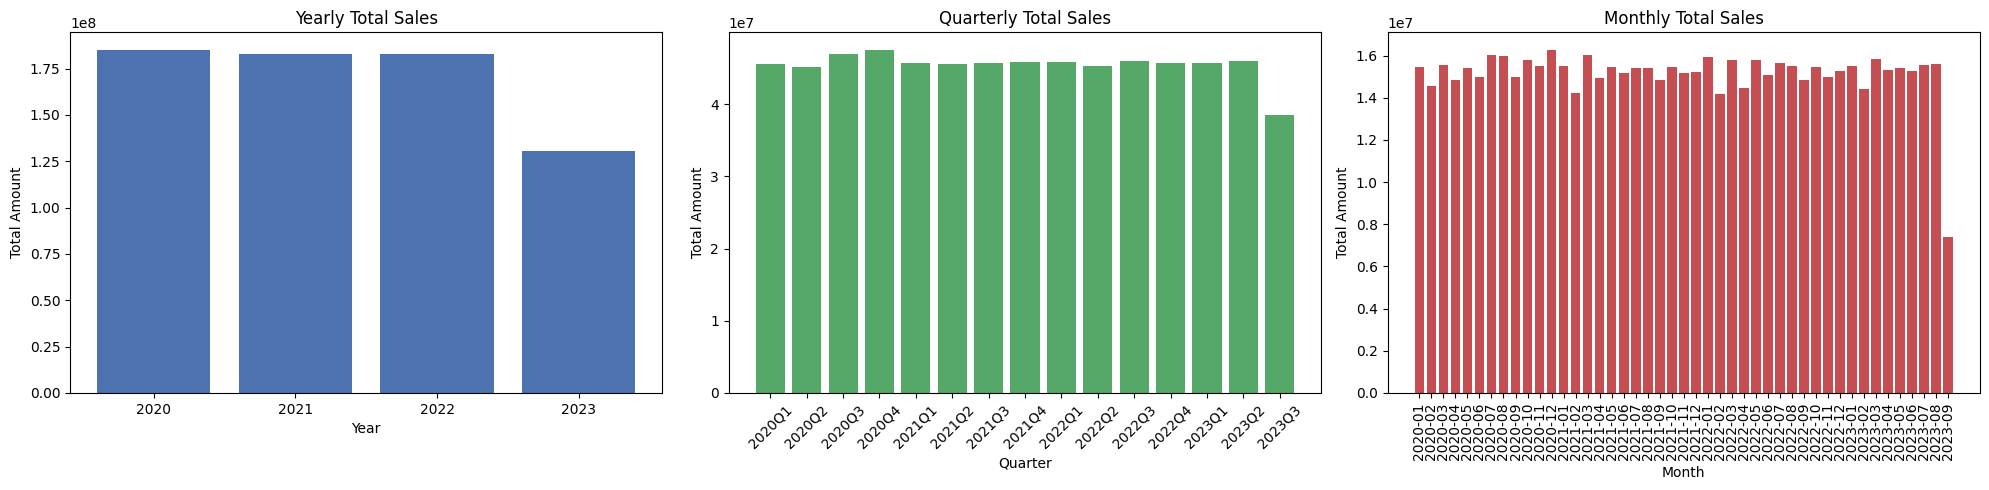

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure Purchase Date is datetime
df["Purchase Date"] = pd.to_datetime(df["Purchase Date"])

# Yearly sales
yearly_sales_df = (
    df.groupby(df["Purchase Date"].dt.year)["Total Purchase Amount"]
    .sum()
    .reset_index()
    .rename(columns={"Purchase Date": "year", "Total Purchase Amount": "total_amount"})
)

# Quarterly sales
quarterly_sales = (
    df.resample("QE", on="Purchase Date")["Total Purchase Amount"]
    .sum()
    .reset_index()
    .rename(columns={"Total Purchase Amount": "total_amount"})
)
quarterly_sales["quarter"] = quarterly_sales["Purchase Date"].dt.to_period("Q").astype(str)

# Monthly sales
monthly_sales = (
    df.resample("ME", on="Purchase Date")["Total Purchase Amount"]
    .sum()
    .reset_index()
    .rename(columns={"Total Purchase Amount": "total_amount"})
)
monthly_sales["month"] = monthly_sales["Purchase Date"].dt.to_period("M").astype(str)

# ----- Bar plots -----
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Yearly bar plot
axes[0].bar(yearly_sales_df["year"].astype(str), yearly_sales_df["total_amount"], color="#4C72B0")
axes[0].set_title("Yearly Total Sales")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Total Amount")
axes[0].tick_params(axis="x", rotation=0)

# Quarterly bar plot
axes[1].bar(quarterly_sales["quarter"], quarterly_sales["total_amount"], color="#55A868")
axes[1].set_title("Quarterly Total Sales")
axes[1].set_xlabel("Quarter")
axes[1].set_ylabel("Total Amount")
axes[1].tick_params(axis="x", rotation=45)

# Monthly bar plot
axes[2].bar(monthly_sales["month"], monthly_sales["total_amount"], color="#C44E52", width=0.8)
axes[2].set_title("Monthly Total Sales")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Total Amount")
axes[2].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

In [46]:
Unique_Customer_ID_count = df["Customer ID"].nunique()
print("Unique_Customer_ID_count :",Unique_Customer_ID_count)

Unique_Customer_ID_count : 49673


# 3. Feature Selection : RFM Analysis -

# Basic aggregates per customer :

In [48]:
# Number of purchases per customer
purchase_count = df.groupby("Customer ID").size().rename("num_purchases")

# Total revenue per customer
customer_revenue = df.groupby("Customer ID")["Total Purchase Amount"].sum().rename("total_revenue")

# First and last purchase date per customer
first_last = (
    df.groupby("Customer ID")["Purchase Date"]
    .agg(["min", "max"])
    .rename(columns={"min": "first_purchase", "max": "last_purchase"})
)

# Combine
customer_metrics = pd.concat(
    [purchase_count, customer_revenue, first_last],
    axis=1
).reset_index()

# Purchase frequency
Standard definition:
Purchase Frequency = Total number of purchases / Number of unique customers

In [50]:
total_orders = len(df)
unique_customers = df["Customer ID"].nunique()

purchase_frequency_overall = total_orders / unique_customers
print("Overall purchase frequency (orders per customer):", purchase_frequency_overall)

Overall purchase frequency (orders per customer): 5.032915265838584


In [52]:
customer_metrics["purchase_frequency"] = customer_metrics["num_purchases"]

# Customer Lifetime Value (CLV)
Basic CLV formula:
CLV = Average Purchase Value × Purchase Frequency × Customer Lifespan

In [54]:
# Estimate time span in years from first to last purchase in dataset
time_span_days = (df["Purchase Date"].max() - df["Purchase Date"].min()).days
time_span_years = time_span_days / 365.25

purchase_frequency_annual = (total_orders / unique_customers) / time_span_years
print("Annualized purchase frequency:", purchase_frequency_annual)

Annualized purchase frequency: 1.358663932629374


In [56]:
avg_purchase_value = df["Total Purchase Amount"].mean()
print("Average purchase value:", avg_purchase_value)

Average purchase value: 2725.370732


In [58]:
customer_metrics["avg_purchase_value"] = (
    customer_metrics["total_revenue"] / customer_metrics["num_purchases"]
)


In [60]:
customer_metrics["lifespan_days"] = (
    customer_metrics["last_purchase"] - customer_metrics["first_purchase"]
).dt.days

# Convert to years
customer_metrics["lifespan_years"] = customer_metrics["lifespan_days"] / 365.25

# For customers with only one purchase, lifespan = 0; you may set a minimum, e.g. 1 year
customer_metrics["lifespan_years"] = customer_metrics["lifespan_years"].replace(0, 1)

In [62]:
avg_lifespan_years = customer_metrics["lifespan_years"].mean()
print("Average customer lifespan (years):", avg_lifespan_years)

Average customer lifespan (years): 2.308897988877374


In [64]:
clv_overall = avg_purchase_value * purchase_frequency_overall * avg_lifespan_years
print("Overall CLV:", clv_overall)

clv_annual = avg_purchase_value * purchase_frequency_annual
print("Annual CLV (per customer per year):", clv_annual)

# Annualized frequency per customer
customer_metrics["purchase_frequency_annual"] = (
    customer_metrics["num_purchases"] / customer_metrics["lifespan_years"]
)

# Per-customer CLV
customer_metrics["clv"] = (
    customer_metrics["avg_purchase_value"]
    * customer_metrics["purchase_frequency_annual"]
    * customer_metrics["lifespan_years"]
)

# Simplifies to total_revenue, but this structure matches the CLV formula conceptually
# You can also define CLV as projected future value using avg metrics:
customer_metrics["clv_projected"] = (
    avg_purchase_value
    * customer_metrics["purchase_frequency_annual"]
    * customer_metrics["lifespan_years"]
)

customer_metrics[["Customer ID", "num_purchases", "total_revenue",
                  "avg_purchase_value", "lifespan_years",
                  "purchase_frequency_annual", "clv_projected"]].head()

Overall CLV: 31670.137710929765
Annual CLV (per customer per year): 3702.8629166121154


,Customer ID,num_purchases,total_revenue,avg_purchase_value,lifespan_years,purchase_frequency_annual,clv_projected
0,1,1,3491,3491.000000,1.000000,1.000000,2725.370732
1,2,3,7988,2662.666667,1.711157,1.753200,8176.112196
2,3,8,22587,2823.375000,2.718686,2.942598,21802.965856
3,4,4,8715,2178.750000,2.587269,1.546032,10901.482928
4,5,8,12524,1565.500000,3.159480,2.532062,21802.965856


In [66]:
gross_margin = 0.30
clv_with_margin = clv_overall * gross_margin
print("CLV with gross margin:", clv_with_margin)

CLV with gross margin: 9501.041313278929


In [68]:
cac = 1000  # example
clv = 31670.14
clv_cac_ratio = clv / cac
print("CLV:CAC ratio:", clv_cac_ratio)

CLV:CAC ratio: 31.67014


# Overall CLV ≈ 31,670: 
# On average, a customer is expected to generate about ₹31,670 of revenue over their entire relationship 
# with the business (using your data and the CLV formula you applied).

# Annual CLV ≈ 3,703: On average, a customer generates about ₹3,703 of revenue per year.

In [70]:
snapshot_date = df["Purchase Date"].max()  # or a fixed date like pd.Timestamp("2024-12-31")

recency = (
    df.groupby("Customer ID")["Purchase Date"]
    .max()
    .reset_index()
    .rename(columns={"Purchase Date": "last_purchase"})
)
recency["Recency"] = (snapshot_date - recency["last_purchase"]).dt.days

In [72]:
frequency = (
    df.groupby("Customer ID")
    .size()
    .reset_index()
    .rename(columns={0: "Frequency"})
)

In [74]:
monetary = (
    df.groupby("Customer ID")["Total Purchase Amount"]
    .sum()
    .reset_index()
    .rename(columns={"Total Purchase Amount": "Monetary"})
)

In [76]:
monetary = (
    df.groupby("Customer ID")["Total Purchase Amount"]
    .sum()
    .reset_index()
    .rename(columns={"Total Purchase Amount": "Monetary"})
)

In [78]:
rfm = pd.merge(recency[["Customer ID", "Recency"]], frequency, on="Customer ID")
rfm = pd.merge(rfm, monetary, on="Customer ID")

# These three columns are your selected features for clustering:
features_for_clustering = rfm[["Recency", "Frequency", "Monetary"]]

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,1,57,1,3491
1,2,298,3,7988
2,3,88,8,22587
3,4,126,4,8715
4,5,170,8,12524


# 4 .Data Normalisation or Standardization Using StandardScalar :

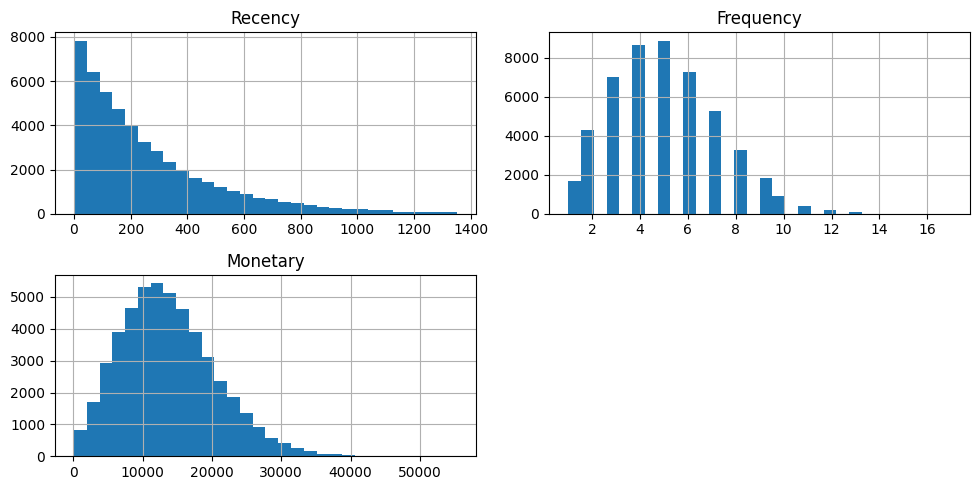

In [81]:
import matplotlib.pyplot as plt
rfm[["Recency","Frequency","Monetary"]].hist(bins=30,figsize=(10,5))
plt.tight_layout()
plt.show()

In [83]:
from sklearn.preprocessing import StandardScaler

features_to_scale = ["Recency", "Frequency", "Monetary"]
rfm_scaled = rfm.copy()

scaler = StandardScaler()

rfm_scaled_array = scaler.fit_transform(rfm_scaled[features_to_scale])

rfm_scaled_df = pd.DataFrame(
    rfm_scaled_array,                             
    columns=[f"{col}_scaled" for col in features_to_scale],
    index=rfm.index
)

rfm_scaled_df.head()

,Recency_scaled,Frequency_scaled,Monetary_scaled
0,-0.826858,-1.827822,-1.494934
1,0.152731,-0.921370,-0.837492
2,-0.700853,1.344760,1.296821
3,-0.546395,-0.468144,-0.731207
4,-0.367549,1.344760,-0.174347


# 5. KMeans Clustering :

In [86]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters = 4,
    random_state = 42,
    n_init = 10
)
rfm_scaled_df["Cluster"] = kmeans.fit_predict(rfm_scaled_df)

# Merge cluster labels back to original RFM table

rfm_with_clusters = pd.concat(
    [rfm.reset_index(drop = True),
     rfm_scaled_df["Cluster"].reset_index(drop = True)],
    axis = 1
)

rfm_with_clusters.head()

,Customer ID,Recency,Frequency,Monetary,Cluster
0,1,57,1,3491,2
1,2,298,3,7988,2
2,3,88,8,22587,0
3,4,126,4,8715,2
4,5,170,8,12524,1


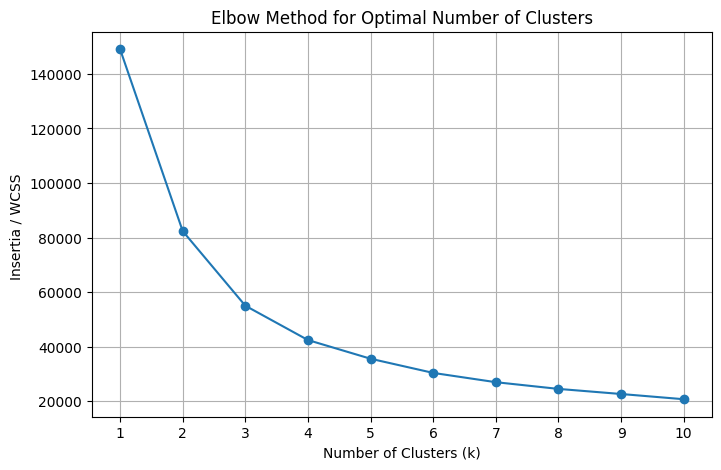

In [90]:
# Elbow method code :

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

X = rfm_scaled_df[["Recency_scaled",
                   "Frequency_scaled",
                   "Monetary_scaled"
                  ]]

inertia = []
k_values = range(1,11)

for k in k_values:
    kmeans = KMeans( n_clusters = k,
                    random_state = 12,
                    n_init = 10
                   )
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot the elbow figure / Curve Dig

plt.figure(figsize=(8,5))
plt.plot(k_values , inertia , marker ="o")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Insertia / WCSS ")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [92]:
optimal_k = 3

final_kmeans = KMeans (
    n_clusters = optimal_k,
    random_state = 42 ,
    n_init = 10
)
rfm["Cluster"] = final_kmeans.fit_predict(X)
print(rfm.head())

   Customer ID  Recency  Frequency  Monetary  Cluster
0            1       57          1      3491        2
1            2      298          3      7988        2
2            3       88          8     22587        0
3            4      126          4      8715        2
4            5      170          8     12524        0


In [94]:
# Check cluster sizes :

cluster_counts = rfm["Cluster"].value_counts().sort_index()
print(cluster_counts)

Cluster
0    16423
1     8746
2    24504
Name: count, dtype: int64


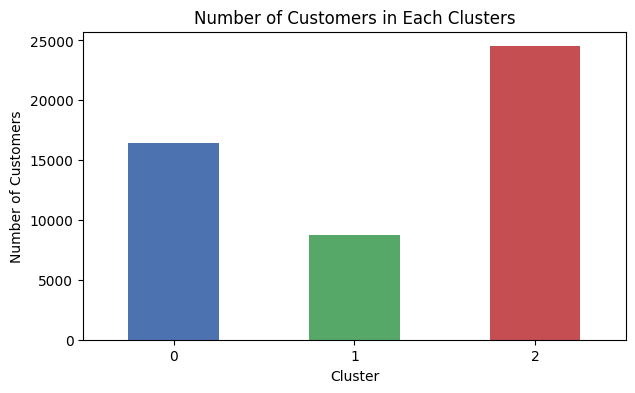

In [96]:
cluster_counts.plot(
    kind = "bar",
    color = ["#4c72B0","#55A868", "#C44E52"],
    figsize = (7,4)
)

plt.title("Number of Customers in Each Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation = 0)
plt.show()

In [98]:
cluster_summary = (
    rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]]
    .mean()
    .round(2)
)

print(cluster_summary)

         Recency  Frequency  Monetary
Cluster                              
0         155.47       7.45  21247.41
1         683.05       2.93   7759.57
2         179.92       4.16  10795.43


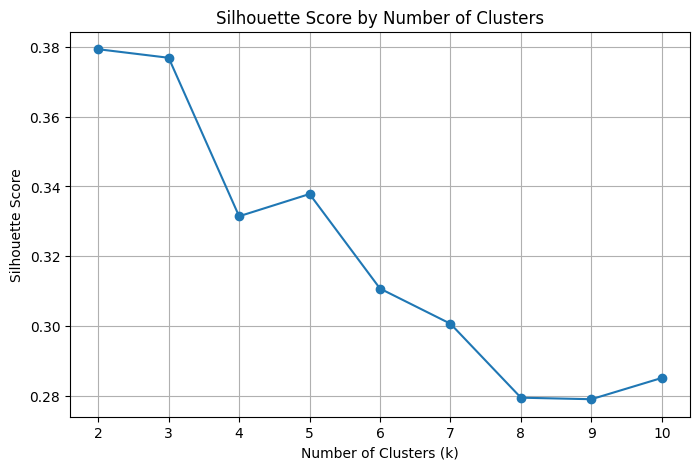

In [100]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

# 6. Cluster Visualizations :

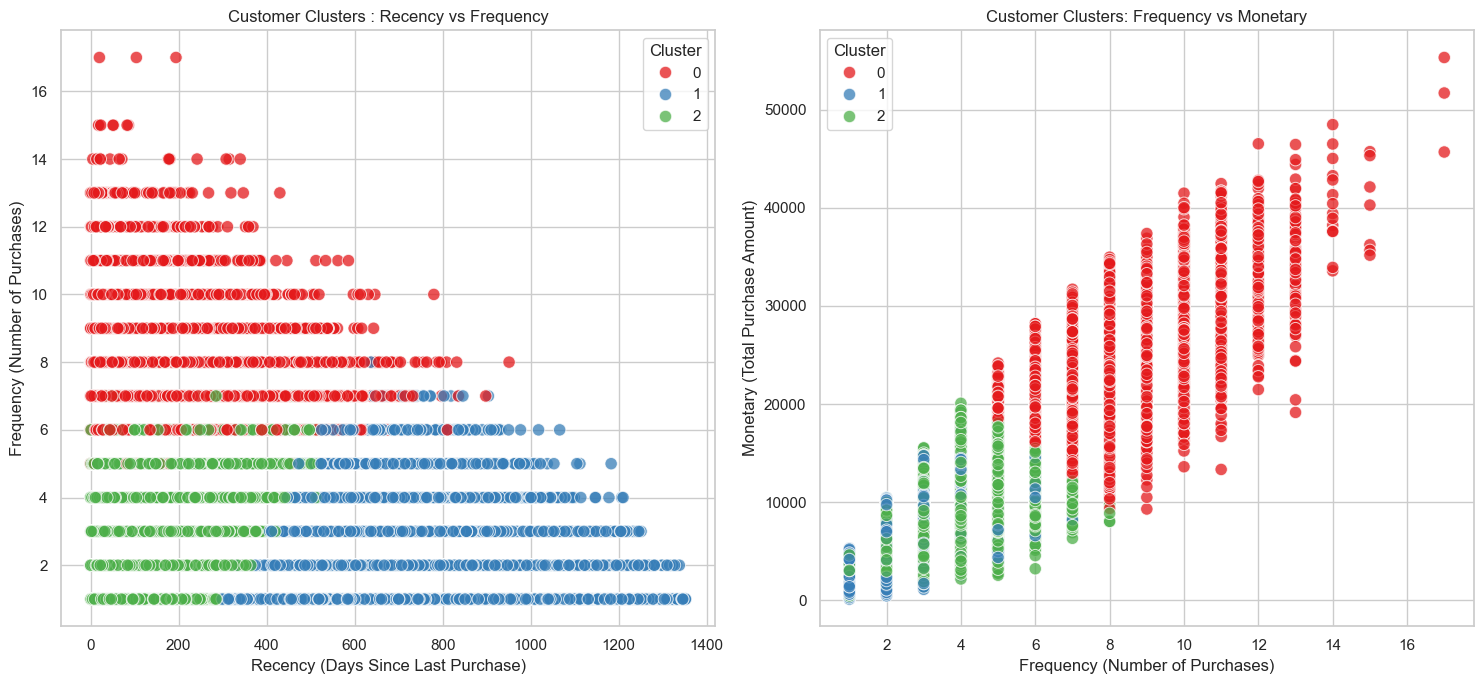

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style ="whitegrid")
fig,axes = plt.subplots(1,2,figsize=(15,7))

# Plot 1: Recency vs Frequency

sns.scatterplot(
    data = rfm,
    x="Recency",y="Frequency",hue="Cluster",
    palette="Set1",s=80,alpha=0.75,ax=axes[0]
)

axes[0].set_title("Customer Clusters : Recency vs Frequency")
axes[0].set_xlabel("Recency (Days Since Last Purchase)")
axes[0].set_ylabel("Frequency (Number of Purchases)")


# Plot 2: Frequency vs Monetary
sns.scatterplot(
    data=rfm,
    x="Frequency",y="Monetary",hue="Cluster",
    palette="Set1",s=80,alpha=0.75,ax=axes[1]
)

axes[1].set_title("Customer Clusters: Frequency vs Monetary")
axes[1].set_xlabel("Frequency (Number of Purchases)")
axes[1].set_ylabel("Monetary (Total Purchase Amount)")

plt.tight_layout()
plt.show()

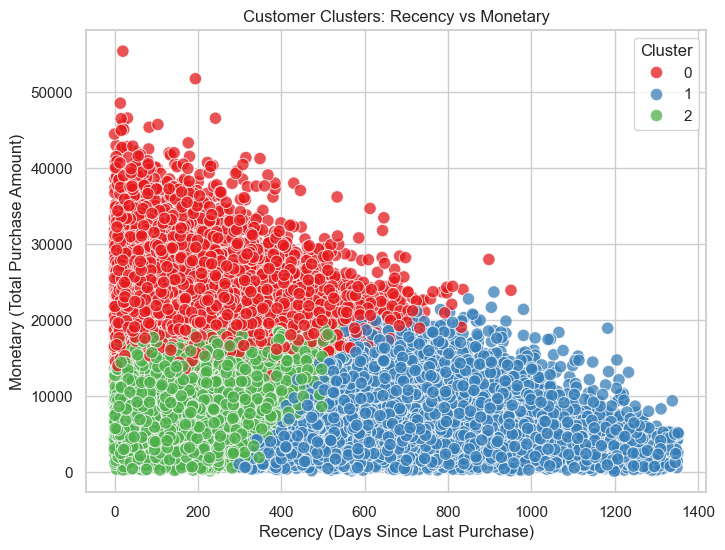

In [106]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="Set1",
    s=80,
    alpha=0.75
)

plt.title("Customer Clusters: Recency vs Monetary")
plt.xlabel("Recency (Days Since Last Purchase)")
plt.ylabel("Monetary (Total Purchase Amount)")
plt.show()

In [112]:
# Profile every Cluster :

cluster_profile = (
    rfm.groupby("Cluster").agg(
        Customer_Count=("Customer ID","count"),
        Avg_Recency=("Recency","mean"),
        Avg_Frequency=("Frequency","mean"),
        Avg_Monetary=("Monetary","mean"),
        Total_Revenue=("Monetary","sum")
    )
    .round(2)
    .sort_values("Avg_Monetary",ascending=False)
)

print(cluster_profile)

         Customer_Count  Avg_Recency  Avg_Frequency  Avg_Monetary  \
Cluster                                                             
0                 16423       155.47           7.45      21247.41   
2                 24504       179.92           4.16      10795.43   
1                  8746       683.05           2.93       7759.57   

         Total_Revenue  
Cluster                 
0            348946278  
2            264531205  
1             67865200  


Add customer-type names :

In [118]:
# Example only: change these names after checking cluster_profile
cluster_names = {
    0: "High-Value Loyal Customers",
    1: "Regular Customers",
    2: "At-Risk / Inactive Customers"
}

rfm["Customer_Type"] = rfm["Cluster"].map(cluster_names)

print(
    rfm[
        ["Customer ID", "Recency", "Frequency", "Monetary",
         "Cluster", "Customer_Type"]
    ].head()
)

   Customer ID  Recency  Frequency  Monetary  Cluster  \
0            1       57          1      3491        2   
1            2      298          3      7988        2   
2            3       88          8     22587        0   
3            4      126          4      8715        2   
4            5      170          8     12524        0   

                  Customer_Type  
0  At-Risk / Inactive Customers  
1  At-Risk / Inactive Customers  
2    High-Value Loyal Customers  
3  At-Risk / Inactive Customers  
4    High-Value Loyal Customers  


# Cluster 0 → low Recency, high Frequency, high Monetary
# Cluster 1 → medium Recency, medium Frequency, medium Monetary
# Cluster 2 → high Recency, low Frequency, low Monetary

In [123]:
# Add product-category personalization :
# dataset also contains Product Category

customer_favorite_category = (
    df.groupby(["Customer ID", "Product Category"])
    .size()
    .reset_index(name="Purchase_Count")
    .sort_values(
        ["Customer ID", "Purchase_Count"],
        ascending=[True, False]
    )
    .drop_duplicates("Customer ID")
)

rfm_marketing = rfm.merge(
    customer_favorite_category[["Customer ID", "Product Category"]],
    on="Customer ID",
    how="left"
)

print(rfm_marketing.head())

   Customer ID  Recency  Frequency  Monetary  Cluster  \
0            1       57          1      3491        2   
1            2      298          3      7988        2   
2            3       88          8     22587        0   
3            4      126          4      8715        2   
4            5      170          8     12524        0   

                  Customer_Type Product Category  
0  At-Risk / Inactive Customers            Books  
1  At-Risk / Inactive Customers            Books  
2    High-Value Loyal Customers         Clothing  
3  At-Risk / Inactive Customers         Clothing  
4    High-Value Loyal Customers         Clothing  


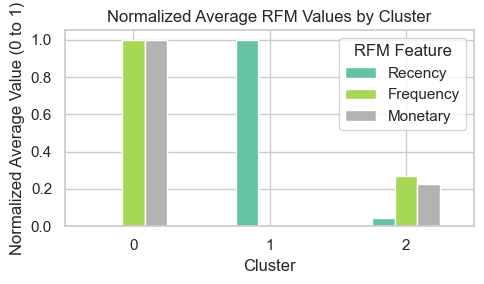

In [131]:
from sklearn.preprocessing import MinMaxScaler

# Average RFM values for each cluster
profile_for_plot = (
    rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]]
    .mean()
)

# Normalize only for comparison in a chart
scaler = MinMaxScaler()
profile_normalized = pd.DataFrame(
    scaler.fit_transform(profile_for_plot),
    columns=profile_for_plot.columns,
    index=profile_for_plot.index
)

profile_normalized.plot(
    kind="bar",
    figsize=(5,3),
    colormap="Set2"
)

plt.title("Normalized Average RFM Values by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Normalized Average Value (0 to 1)")
plt.xticks(rotation=0)
plt.legend(title="RFM Feature")
plt.tight_layout()
plt.show()

In [137]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = rfm[["Recency", "Frequency", "Monetary"]]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

optimal_k = 3 

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

# fit_predict both trains K-Means and returns cluster labels
rfm["Cluster"] = kmeans.fit_predict(X_scaled)

# Calculate silhouette score
silhouette_avg = silhouette_score(X_scaled, rfm["Cluster"])

print("Silhouette Score:", round(silhouette_avg, 3))

Silhouette Score: 0.377


In [145]:
# Compare possible k-values :

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt

results = []

for k in range(2,11):
    model = KMeans(
        n_clusters = k,
        random_state=42,
        n_init = 10
    )

labels = model.fit_predict(X_scaled)
results.append(
    {
        "k":k,
        "Inertia":model.inertia_,
        "Silhouette Score":silhouette_score(X_scaled,labels)
    }
)
k_evaluation = pd.DataFrame(results)
print(k_evaluation)



    k      Inertia  Silhouette Score
0  10  20769.93676          0.285184


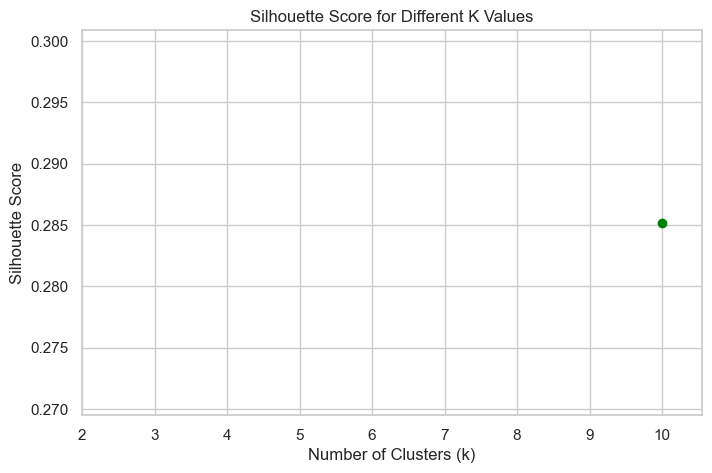

In [147]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_evaluation["k"],
    k_evaluation["Silhouette Score"],
    marker="o",
    color="green"
)

plt.title("Silhouette Score for Different K Values")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [149]:
cluster_business_summary = (
    rfm.groupby("Cluster")
    .agg(
        Customer_Count=("Customer ID", "count"),
        Total_Revenue=("Monetary", "sum"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean")
    )
    .round(2)
)

cluster_business_summary["Customer_Percentage"] = (
    cluster_business_summary["Customer_Count"]
    / cluster_business_summary["Customer_Count"].sum()
    * 100
).round(2)

cluster_business_summary["Revenue_Percentage"] = (
    cluster_business_summary["Total_Revenue"]
    / cluster_business_summary["Total_Revenue"].sum()
    * 100
).round(2)

print(cluster_business_summary.sort_values("Total_Revenue", ascending=False))

         Customer_Count  Total_Revenue  Avg_Recency  Avg_Frequency  \
Cluster                                                              
0                 16423      348946278       155.47           7.45   
2                 24504      264531205       179.92           4.16   
1                  8746       67865200       683.05           2.93   

         Avg_Monetary  Customer_Percentage  Revenue_Percentage  
Cluster                                                         
0            21247.41                33.06               51.21  
2            10795.43                49.33               38.82  
1             7759.57                17.61                9.96  


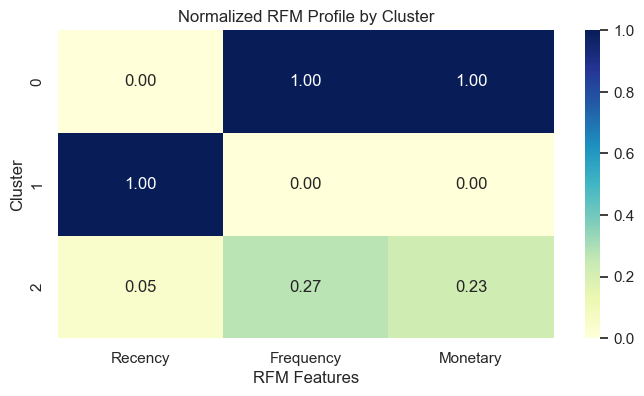

In [151]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

rfm_profile = (
    rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]]
    .mean()
)

# Normalize only for comparing the three features in one heatmap
scaler = MinMaxScaler()
rfm_profile_scaled = pd.DataFrame(
    scaler.fit_transform(rfm_profile),
    columns=rfm_profile.columns,
    index=rfm_profile.index
)

plt.figure(figsize=(8, 4))

sns.heatmap(
    rfm_profile_scaled,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Normalized RFM Profile by Cluster")
plt.xlabel("RFM Features")
plt.ylabel("Cluster")
plt.show()

In [155]:
print(df["Churn"].value_counts())

Churn
0    200126
1     49874
Name: count, dtype: int64


In [157]:
customer_churn = (
    df.groupby("Customer ID")["Churn"]
    .first()
    .reset_index()
)

rfm_churn = rfm.merge(customer_churn, on="Customer ID", how="left")

churn_by_cluster = (
    rfm_churn.groupby("Cluster")["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .unstack(fill_value=0)
)

print(churn_by_cluster)

Churn        0      1
Cluster              
0        80.25  19.75
1        79.92  20.08
2        79.83  20.17


In [159]:
customer_churn = (
    df.groupby("Customer ID")["Churn"]
    .first()
    .reset_index()
)

rfm_churn = rfm.merge(customer_churn, on="Customer ID", how="left")

churn_rate = (
    rfm_churn.groupby("Cluster")["Churn"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name="Churn_Rate_Percentage")
)

print(churn_rate)

   Cluster  Churn_Rate_Percentage
0        0                  19.75
1        1                  20.08
2        2                  20.17


In [161]:
# Add cluster to transaction-level dataset
df_clustered = df.merge(
    rfm[["Customer ID", "Cluster"]],
    on="Customer ID",
    how="left"
)

# Number of purchases by category for each cluster
cluster_category_counts = (
    df_clustered.groupby(["Cluster", "Product Category"])
    .size()
    .reset_index(name="Purchase_Count")
)

# Top category in each cluster
top_category_by_cluster = (
    cluster_category_counts
    .sort_values(
        ["Cluster", "Purchase_Count"],
        ascending=[True, False]
    )
    .drop_duplicates("Cluster")
)

print(top_category_by_cluster)

   Cluster Product Category  Purchase_Count
1        0         Clothing           36755
5        1         Clothing            7653
8        2            Books           30669


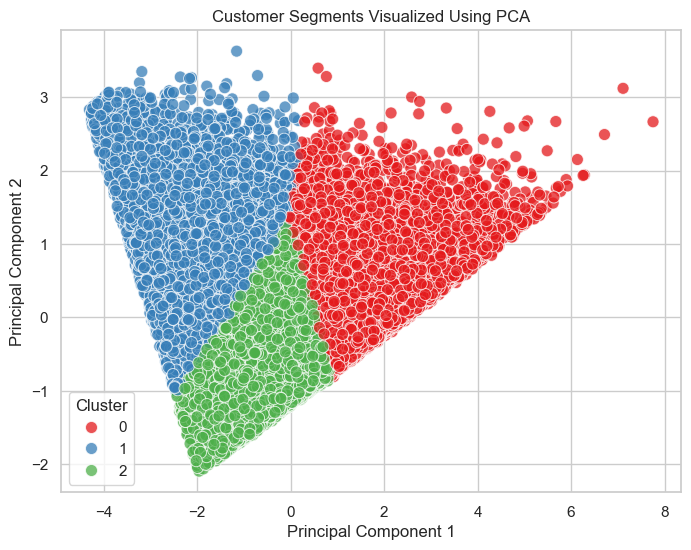

Explained variance: 0.96021948015851


In [165]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

pca = PCA(n_components=2)

pca_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    pca_components,
    columns=["PCA1", "PCA2"]
)

pca_df["Cluster"] = rfm["Cluster"].values

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set1",
    s=75,
    alpha=0.75
)

plt.title("Customer Segments Visualized Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

print(
    "Explained variance:",
    pca.explained_variance_ratio_.sum()
)